In [1]:
import json
from pathlib import Path

# Path to the dataset, relative to this notebook's location (notebooks/)
data_path = Path("../data/curated_papers_text.json")

with open(data_path, "r", encoding="utf-8") as f:
    papers = json.load(f)

print(f"Number of papers: {len(papers)}")
print(f"Keys in each paper record: {list(papers[0].keys())}")

Number of papers: 10
Keys in each paper record: ['id', 'title', 'category', 'pdf_url', 'total_pages', 'pages']


In [2]:
for p in papers:
    print(f"{p['id']:15s} | {p['category']:15s} | pages={p['total_pages']:3d} | {p['title']}")

2005.11401      | RAG             | pages= 19 | Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
2312.10997      | RAG Survey      | pages= 21 | Retrieval-Augmented Generation for Large Language Models: A Survey
2310.11511      | Self-Correction | pages= 30 | Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection
2401.15884      | Corrective RAG  | pages= 16 | Corrective Retrieval Augmented Generation (CRAG)
2210.03629      | Agent Reasoning | pages= 33 | ReAct: Synergizing Reasoning and Acting in Language Models
2307.03172      | Context Windows | pages= 18 | Lost in the Middle: How Language Models Use Long Contexts
2309.15217      | Evaluation      | pages=  8 | RAGAS: Automated Evaluation of Retrieval Augmented Generation
2106.09685      | Model Architecture | pages= 26 | LoRA: Low-Rank Adaptation of Large Language Models
2205.14135      | Systems         | pages= 34 | FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness

In [3]:
import pandas as pd

records = []
for p in papers:
    full_text = " ".join(page["text"] for page in p["pages"])
    records.append({
        "id": p["id"],
        "title": p["title"],
        "category": p["category"],
        "total_pages": p["total_pages"],
        "word_count": len(full_text.split()),
        "char_count": len(full_text),
    })

df = pd.DataFrame(records)
df

,id,title,category,total_pages,word_count,char_count
0,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,19,9885,69076
1,2312.10997,Retrieval-Augmented Generation for Large Langu...,RAG Survey,21,15860,109959
2,2310.11511,"Self-RAG: Learning to Retrieve, Generate, and ...",Self-Correction,30,16143,105729
3,2401.15884,Corrective Retrieval Augmented Generation (CRAG),Corrective RAG,16,9060,61308
4,2210.03629,ReAct: Synergizing Reasoning and Acting in Lan...,Agent Reasoning,33,16970,110106
5,2307.03172,Lost in the Middle: How Language Models Use Lo...,Context Windows,18,9773,65423
6,2309.15217,RAGAS: Automated Evaluation of Retrieval Augme...,Evaluation,8,4919,31944
7,2106.09685,LoRA: Low-Rank Adaptation of Large Language Mo...,Model Architecture,26,13347,82496
8,2205.14135,FlashAttention: Fast and Memory-Efficient Exac...,Systems,34,16804,108143
9,2004.04906,Dense Passage Retrieval for Open-Domain Questi...,Embeddings,13,8816,55933


In [4]:
df[["total_pages", "word_count", "char_count"]].describe()

,total_pages,word_count,char_count
count,10.000000,10.000000,10.000000
mean,21.800000,12157.700000,80011.700000
std,8.715248,4213.257543,27555.932308
min,8.000000,4919.000000,31944.000000
25%,16.500000,9238.250000,62336.750000
50%,20.000000,11616.000000,75786.000000
75%,29.000000,16072.250000,107539.500000
max,34.000000,16970.000000,110106.000000


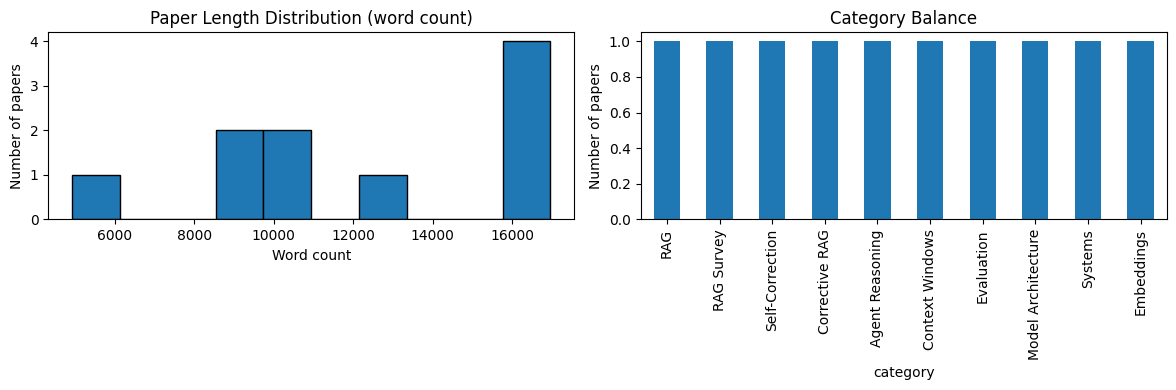

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_count"], bins=10, edgecolor="black")
axes[0].set_title("Paper Length Distribution (word count)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of papers")

df["category"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Category Balance")
axes[1].set_ylabel("Number of papers")

plt.tight_layout()
plt.show()

In [6]:
import re
import ftfy

ARXIV_HEADER_RE = re.compile(
    r"arXiv:\d{4}\.\d{4,5}v\d+\s*\[[\w\.\-]+\]\s*\d{1,2}\s+\w+\s+\d{4}"
)
PAGE_NUMBER_RE = re.compile(r"\n\s*\d{1,4}\s*\n")
REFERENCES_HEADING_RE = re.compile(r"\n\s*References\s*\n", re.IGNORECASE)

def clean_page_text(text: str) -> str:
    text = ftfy.fix_text(text)                 # fixes ligatures (ﬁ, ﬂ) and encoding artifacts
    text = ARXIV_HEADER_RE.sub(" ", text)       # strips inline arXiv running headers
    text = PAGE_NUMBER_RE.sub("\n", text)       # strips standalone page-number lines
    text = re.sub(r"[ \t]{2,}", " ", text)      # collapse extra spaces
    text = re.sub(r"\n{2,}", "\n", text)        # collapse extra blank lines
    return text.strip()

def strip_references_section(full_text: str) -> str:
    match = REFERENCES_HEADING_RE.search(full_text)
    if match:
        return full_text[:match.start()].strip()
    return full_text

In [7]:
raw_snippet = papers[0]["pages"][0]["text"][:500]
clean_snippet = clean_page_text(papers[0]["pages"][0]["text"])[:500]

print("RAW:\n", raw_snippet)
print("\nCLEANED:\n", clean_snippet)

RAW:
 Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research;‡University College London;⋆New York University;
plewis@fb.com
Abstract
Large pre-trained language models have been shown to store factual knowledge
in their parameters, and achieve state-of-the-art results when ﬁ

CLEANED:
 Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research;‡University College London;⋆New York University;
plewis@fb.com
Abstract
Large pre-trained language models have been shown to store factual knowledge
in their parameters, and achieve state-of-the-

In [8]:
print("RAW around ligature:\n", papers[0]["pages"][0]["text"][470:540])
print("\nCLEANED around ligature:\n", clean_page_text(papers[0]["pages"][0]["text"])[470:540])

RAW around ligature:
 tate-of-the-art results when ﬁne-tuned on down-
stream NLP tasks. Howe

CLEANED around ligature:
 tate-of-the-art results when fine-tuned on down-
stream NLP tasks. How


In [9]:
for page in papers[0]["pages"]:
    if "arXiv:" in page["text"]:
        idx = page["text"].find("arXiv:")
        raw_chunk = page["text"][max(0, idx-30):idx+60]
        clean_chunk = clean_page_text(page["text"])
        print(f"Page {page['page_number']} RAW:   ...{raw_chunk}...")
        print(f"Page {page['page_number']} has 'arXiv:' in cleaned version? {'arXiv:' in clean_chunk}")
        print()

Page 1 RAW:   ...have shown promising results,
arXiv:2005.11401v4  [cs.CL]  12 Apr 2021...
Page 1 has 'arXiv:' in cleaned version? False

Page 10 RAW:   ...eading COmprehension Dataset. arXiv:1611.09268 [cs], November 2016. URL http:
//arxiv.org/...
Page 10 has 'arXiv:' in cleaned version? True

Page 11 RAW:   ...raph Reading Compre-
hension. arXiv:1710.10723 [cs], October 2017. URL http://arxiv.org/ab...
Page 11 has 'arXiv:' in cleaned version? True

Page 12 RAW:   ...rch with gpus. arXiv
preprint arXiv:1702.08734, 2017. URL https://arxiv.org/abs/1702.08734...
Page 12 has 'arXiv:' in cleaned version? True

Page 13 RAW:   ...comprehension. arXiv preprint
arXiv:1910.13461, 2019. URL https://arxiv.org/abs/1910.13461...
Page 13 has 'arXiv:' in cleaned version? True

Page 14 RAW:   ...ing with BERT. arXiv preprint
arXiv:1901.04085, 2019. URL https://arxiv.org/abs/1901.04085...
Page 14 has 'arXiv:' in cleaned version? True



In [10]:
import re
import unicodedata
import ftfy

ARXIV_HEADER_RE = re.compile(
    r"arXiv:\d{4}\.\d{4,5}v\d+\s*\[[\w\.\-]+\]\s*\d{1,2}\s+\w+\s+\d{4}"
)
PAGE_NUMBER_RE = re.compile(r"\n\s*\d{1,4}\s*\n")
REFERENCES_HEADING_RE = re.compile(r"\n\s*References\s*\n", re.IGNORECASE)
HYPHEN_LINEBREAK_RE = re.compile(r"(\w)-\s*\n\s*(\w)")
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]+")

_CLEAN_TOKEN_RE = re.compile(r"^[A-Za-z0-9,.:;!?'\"()\[\]/\-]+$")


def _shift_decode_char(ch: str, shift: int) -> str:
    o = ord(ch)
    if ch in "\n\t\r" or o >= 127:
        return ch
    return chr((o + shift) % 127)


def _shift_decode(text: str, shift: int) -> str:
    return "".join(_shift_decode_char(c, shift) for c in text)


def _token_purity(text: str) -> float:
    """Fraction of whitespace-split tokens that look like plain words/punctuation.
    A correct decode of real English text scores far higher on this than a wrong
    shift does (wrong shifts can coincidentally match English letter-frequency
    stats on a short sample, but still scatter stray symbols through the tokens)."""
    tokens = text.split()
    if not tokens:
        return 0.0
    clean = sum(1 for t in tokens if _CLEAN_TOKEN_RE.match(t))
    return clean / len(tokens)


def repair_font_encoding_artifacts(text: str, min_score: float = 0.85) -> str:
    """Some PDFs embed a custom/subset font for example blocks (e.g. the
    ALFWorld transcripts in the ReAct paper's appendix) whose character codes
    don't map to the letters they actually display. Naive PDF-to-text
    extraction reads the raw font codes literally, producing shifted,
    space-less runs like 'HQGUDZHU' instead of 'end drawer'. This is already
    present in our raw curated_papers_text.json -- it's a PDF-extraction
    artifact, not something our own cleaning introduces.

    These runs never contain a real space (the font's own space glyph sits
    outside the normal printable range) and do contain raw control
    characters, which normal extracted text never does -- so we detect them
    line by line. For each detected run we brute-force every additive shift
    over the printable ASCII range and keep whichever shift produces the
    most recognizable English words, only accepting the decode if it clears
    a minimum score. That way a stray control character inside an unrelated
    equation is left alone instead of being scrambled by a bad guess.
    """
    lines = text.split("\n")

    def is_suspicious(line):
        if len(line) <= 8 or " " in line:
            return False
        return any(ord(c) < 32 and c not in "\n\t\r" for c in line)

    out_lines, run = [], []

    def flush_run():
        if not run:
            return
        block = "\n".join(run)
        best_shift, best_score = 0, -1.0
        for shift in range(127):
            s = _token_purity(_shift_decode(block, shift))
            if s > best_score:
                best_score, best_shift = s, shift
        if best_score >= min_score:
            out_lines.append(_shift_decode(block, best_shift))
        else:
            out_lines.append(block)  # not confidently decodable -- leave as-is
        run.clear()

    for line in lines:
        if is_suspicious(line):
            run.append(line)
        else:
            flush_run()
            out_lines.append(line)
    flush_run()

    return "\n".join(out_lines)


def _strip_accents(text: str) -> str:
    """Transliterate accented Latin letters (Kuttler, Rocktaschel, ...) to
    their plain ASCII form instead of just deleting them."""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))


def normalize_unicode_text(text: str) -> str:
    """Normalize Unicode noise while preserving readable text."""
    text = repair_font_encoding_artifacts(text)  # must run first -- needs the raw control chars intact
    text = ftfy.fix_text(text)
    text = unicodedata.normalize("NFKC", text)   # folds math-italic letters (𝑥,𝑑,...) to plain ASCII letters
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\u00a0", " ")
    text = "".join(ch for ch in text if ch.isprintable() or ch in "\n\t")
    text = text.replace("\u200b", "").replace("\ufeff", "")
    text = _strip_accents(text)                  # e.g. Kuttler stays readable instead of becoming "K ttler"
    text = NON_ASCII_RE.sub(" ", text)           # drop remaining non-ASCII: Greek letters, math operators, dashes, bullets, ...
    text = re.sub(r"[ \t]{2,}", " ", text)
    return text.strip()


def clean_page_text(text: str) -> str:
    text = normalize_unicode_text(text)
    text = ARXIV_HEADER_RE.sub(" ", text)
    text = PAGE_NUMBER_RE.sub("\n", text)
    text = HYPHEN_LINEBREAK_RE.sub(r"\1\2", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text.strip()


def strip_references_section(full_text: str) -> str:
    match = REFERENCES_HEADING_RE.search(full_text)
    if match:
        return full_text[:match.start()].strip()
    return full_text


In [11]:
print(clean_page_text(papers[0]["pages"][0]["text"])[470:540])

e-of-the-art results when fine-tuned on downstream NLP tasks. However,


In [12]:
for page in papers[0]["pages"]:
    if "arXiv:" in page["text"]:
        idx = page["text"].find("arXiv:")
        raw_chunk = page["text"][max(0, idx-30):idx+60]
        clean_chunk = clean_page_text(page["text"])
        print(f"Page {page['page_number']} RAW:   ...{raw_chunk}...")
        print(f"Page {page['page_number']} has 'arXiv:' in cleaned version? {'arXiv:' in clean_chunk}")
        print()

Page 1 RAW:   ...have shown promising results,
arXiv:2005.11401v4  [cs.CL]  12 Apr 2021...
Page 1 has 'arXiv:' in cleaned version? False

Page 10 RAW:   ...eading COmprehension Dataset. arXiv:1611.09268 [cs], November 2016. URL http:
//arxiv.org/...
Page 10 has 'arXiv:' in cleaned version? True

Page 11 RAW:   ...raph Reading Compre-
hension. arXiv:1710.10723 [cs], October 2017. URL http://arxiv.org/ab...
Page 11 has 'arXiv:' in cleaned version? True

Page 12 RAW:   ...rch with gpus. arXiv
preprint arXiv:1702.08734, 2017. URL https://arxiv.org/abs/1702.08734...
Page 12 has 'arXiv:' in cleaned version? True

Page 13 RAW:   ...comprehension. arXiv preprint
arXiv:1910.13461, 2019. URL https://arxiv.org/abs/1910.13461...
Page 13 has 'arXiv:' in cleaned version? True

Page 14 RAW:   ...ing with BERT. arXiv preprint
arXiv:1901.04085, 2019. URL https://arxiv.org/abs/1901.04085...
Page 14 has 'arXiv:' in cleaned version? True



In [13]:
full_text_page0 = "\n".join(clean_page_text(page["text"]) for page in papers[0]["pages"])
print(f"Full cleaned length before stripping references: {len(full_text_page0)}")

body_only = strip_references_section(full_text_page0)
print(f"Length after stripping references: {len(body_only)}")

print("\nLast 300 characters of body (should NOT look like a reference list):\n")
print(body_only[-300:])

Full cleaned length before stripping references: 68999
Length after stripping references: 37247

Last 300 characters of body (should NOT look like a reference list):

on this
paper, as well as HuggingFace for their help in open-sourcing code to run RAG models. The authors
would also like to thank Kyunghyun Cho and Sewon Min for productive discussions and advice. EP
thanks supports from the NSF Graduate Research Fellowship. PL is supported by the FAIR PhD
program.


In [14]:
def join_and_clean_pages(cleaned_pages: list) -> str:
    """Join per-page cleaned text into one string.

    clean_page_text() strips a standalone page-number line, but only when a
    newline appears on BOTH sides of the digits. A page number sitting at the
    very end (or start) of a page's raw text has a newline on only one side
    within that single page, so it survives per-page cleaning. Once pages are
    joined with "\n", that leftover digit does end up with newlines on both
    sides -- so we run PAGE_NUMBER_RE again on the joined text to catch it.
    """
    joined = "\n".join(page["text"] for page in cleaned_pages)
    joined = PAGE_NUMBER_RE.sub("\n", joined)
    joined = re.sub(r"\n{2,}", "\n", joined)
    return joined.strip()


cleaned_papers = []

for p in papers:
    cleaned_pages = [
        {"page_number": page["page_number"], "text": clean_page_text(page["text"])}
        for page in p["pages"]
    ]
    full_clean_text = join_and_clean_pages(cleaned_pages)
    full_clean_text = strip_references_section(full_clean_text)

    cleaned_papers.append({
        "id": p["id"],
        "title": p["title"],
        "category": p["category"],
        "pdf_url": p["pdf_url"],
        "total_pages": p["total_pages"],
        "pages": cleaned_pages,              # per-page cleaned text (ligatures/headers/hyphenation fixed)
        "clean_full_text": full_clean_text,  # whole-paper text, boundary artifacts removed, References section removed
    })

print(f"Cleaned {len(cleaned_papers)} papers")
for cp in cleaned_papers:
    print(f"{cp['id']:15s} | body chars: {len(cp['clean_full_text']):6d}")


Cleaned 10 papers
2005.11401      | body chars:  37222
2312.10997      | body chars:  73797
2310.11511      | body chars:  44765
2401.15884      | body chars:  38338
2210.03629      | body chars:  42256
2307.03172      | body chars:  43012
2309.15217      | body chars:  20937
2106.09685      | body chars:  44178
2205.14135      | body chars:  37873
2004.04906      | body chars:  38698


In [15]:
import json

# Save cleaned dataset
output_path = Path("../data/cleaned_papers_text.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(cleaned_papers, f, indent=2, ensure_ascii=False)

# Save profiling summary table (from Step 5) alongside it
profile_path = Path("../data/paper_profile_summary.csv")
df.to_csv(profile_path, index=False)

print(f"Saved cleaned dataset to {output_path.resolve()}")
print(f"Saved profile summary to {profile_path.resolve()}")

Saved cleaned dataset to /sessions/rcw-01btpsxkh1wxarqrrxp5kj1q/mnt/Documents/Zayi/data/cleaned_papers_text.json
Saved profile summary to /sessions/rcw-01btpsxkh1wxarqrrxp5kj1q/mnt/Documents/Zayi/data/paper_profile_summary.csv
